<a href="https://colab.research.google.com/github/alexsandoval05/telecom_analysis/blob/main/S7_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(15)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
5,10005,Luis,Garcia,61,MTY,2022-01-02 08:51:29.572393098,Basico,NaN
6,10006,Sofia,Lopez,39,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN
7,10007,Sofia,Gomez,70,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN
8,10008,Sofia,Garcia,76,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN
9,10009,Mateo,Torres,47,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN


In [ ]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

users.isna().sum() # cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
usage.isna().sum() # cantidad de nulos para users
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  **RTA: La columna city tiene 11,7% de vacios, churn date tiene 88.35% de vacios (No se tendra en cuenta), date tiene 0.1% de vacíos, duration tiene 55.19% de vacios y length tiene 44.7% de vacios.**
- Indica qué harías: ¿imputar, eliminar, ignorar? **RTA: Se investigara la columna city de "users" para saber si se imputa o se dejan como nulos. Por otro lado "duration" y "length" estan logicamente vacios pues depende si fueron llamadas o llamadas de texto. Por tal razon no se tendran en cuenta.**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
print(users[['user_id', 'age']].describe()) # explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` **Se observa codigos de usuarios sin vacios**
- La columna `age` **Se evidencian datos no logicos "-999" los cuales afectan este estudio y se debe buscar una forma de mitigar**

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe(),"\n")
print(users[columnas_user].value_counts())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595 

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` **Hay 7 ciudades de las cuales bogota es la mas presente con 808 registros de 3531, 65 ciudades con "?" y 31 ciudades con vacio**
- La columna `plan` **Hay dos planes y el plan basico tiene 2595 registos de 4000 posibles**

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` :**presenta dos tipos de registos, de los cuales "text" se encuentra 22092 veces con respecto al total de 40000**

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  **se evidenciaron datos invalidos "-999" en "age"**
- ¿Qué acción tomarías?  **Es importante saber cuantos datos invalidos se evidencian por medio de una box plot y ver como actuar**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce", utc=True)# completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage["date"] =  pd.to_datetime(usage["date"], errors="coerce", utc=True)# completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["year"]  = users["reg_date"].dt.year
print(users["year"].unique())


[2022 2026 2023 2024]


En `reg_date`, **se evidencia que no hay vacíos y los años que se mencionan son: 2022, 2023, 2024 y 2026**

In [ ]:
# Revisar los años presentes en `date` de usage
usage["year"] = usage["date"].dt.year
print(usage["year"].unique())

[2024.   nan]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  **se observa que el año que se menciona es 2024 y hay presencia de vacios**
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**Si aparecen años muy viejos que no son logicos**
- ¿Qué harías con ellas? **Para facilidad en esta evaluacion yo trabajaria con el año 2024 pues es el año comun entre ambas tablas.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(),"\n")
print(users['city'].describe())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64 

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['year'] = users['year'].replace(2026, pd.NA)

# Verificar cambios
print(users['year'].describe(),"\n")
print(users['year'].value_counts())

count     3960
unique       3
top       2024
freq      1330
Name: year, dtype: int64 

2024    1330
2023    1316
2022    1314
Name: year, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_is_null'] = usage['duration'].isna()
print(usage.groupby("type")['duration_is_null'].mean())


type
call    0.000000
text    0.999276
Name: duration_is_null, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_is_null'] = usage['length'].isna()
print(usage.groupby("type")['length_is_null'].mean())

type
call    0.99933
text    0.00000
Name: length_is_null, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
**Se observa que la cantidad de nulos para "duration" y "length" si depende del "type" de comunicacion ya sea "text" en donde se encuentran los valores de "length" o "call" en donde se encuentran los valores de "duration**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby(['type','user_id'])
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum',
            })
.reset_index())

# observar resultado
usage_agg.head()

,type,user_id,is_text,is_call,duration
0,call,10000,0,3,23.70
1,call,10001,0,10,33.18
2,call,10002,0,2,10.74
3,call,10003,0,3,8.99
4,call,10004,0,3,8.01


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas'})

# observar resultado
usage_agg.head(3)

,type,user_id,cant_mensajes,cant_llamadas,duration
0,call,10000,0,3,23.70
1,call,10001,0,10,33.18
2,call,10002,0,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(users,usage_agg, on=['user_id'], how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,type,cant_mensajes,cant_llamadas,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,call,0.0,3.0,23.70
1,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,text,7.0,0.0,0.00
2,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,call,0.0,10.0,33.18
3,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,text,5.0,0.0,0.00
4,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,call,0.0,2.0,10.74


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile_2024 = user_profile[user_profile["year"] == 2024]
print(user_profile_2024[['user_id', 'age', 'year', 'cant_mensajes', 'cant_llamadas','duration']].describe())

            user_id          age  cant_mensajes  cant_llamadas     duration
count   2646.000000  2646.000000     2646.00000    2646.000000  2646.000000
mean   13332.317838    48.388889        2.76455       2.290627    12.127162
std      385.042118    17.975333        3.22750       2.737785    17.912313
min    12666.000000    18.000000        0.00000       0.000000     0.000000
25%    12998.000000    33.000000        0.00000       0.000000     0.000000
50%    13332.500000    48.000000        1.00000       0.000000     0.555000
75%    13665.750000    64.000000        5.00000       4.000000    20.550000
max    13999.000000    79.000000       16.00000      13.000000   155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print("Distribucion porcentual 2024 - Tipo de plan:")
print(user_profile_2024['plan'].value_counts(normalize=True))


Distribucion porcentual 2024 - Tipo de plan:
Basico     0.656085
Premium    0.343915
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

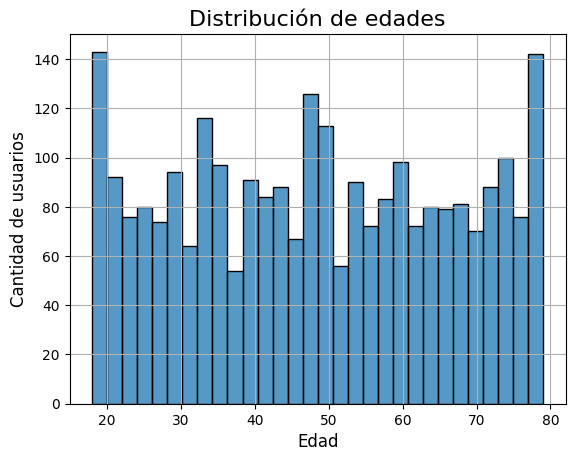

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile_2024, x="age", bins=30)
plt.title("Distribución de edades", fontsize=16)
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.grid(True)

plt.show()


💡Insights: Gráfica multimodal con dos picos de mayor tendencia en 20 y 80 años
- Distribución tipo normal sin tendencia ni sesgo.

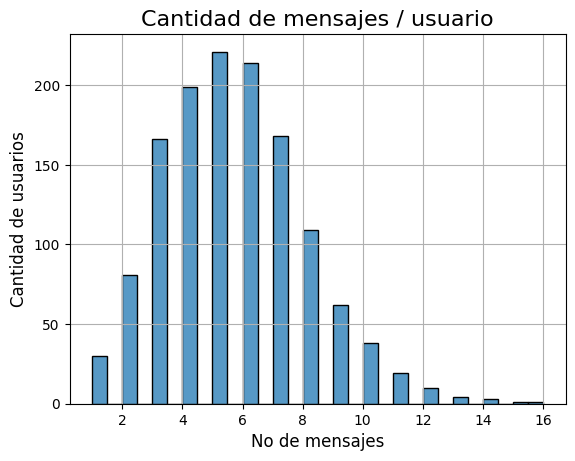

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile_2024[user_profile_2024["cant_mensajes"] > 0], x="cant_mensajes", bins=30)
plt.title("Cantidad de mensajes / usuario", fontsize=16)
plt.xlabel("No de mensajes", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.grid(True)
plt.show()

💡Insights:
- Se empezó por filtrar la cantidad de mensajes mayores a 0 para observar claramente la tendencia.

💡Insights:
- Distribución con sesgo a la derecha en donde la mediana es el valor mas representativo para la distribucion de estos datos.

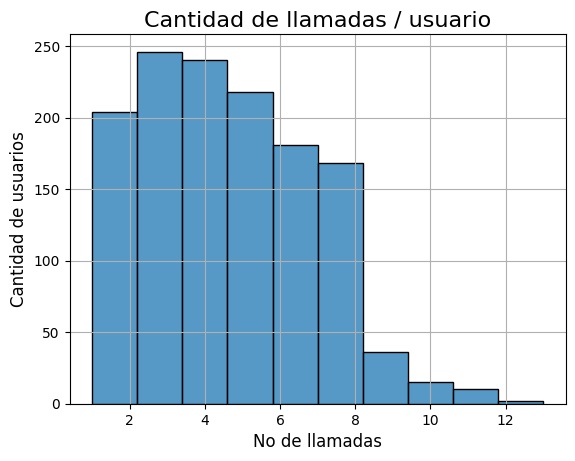

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile_2024[user_profile_2024["cant_llamadas"] > 0], x="cant_llamadas", bins=10)
plt.title("Cantidad de llamadas / usuario", fontsize=16)
plt.xlabel("No de llamadas", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.grid(True)
plt.show()


💡Insights:
- Para la **"cantidad de llamadas"** se evidencia distribucion con sesgo a la derecha en donde la mediana es el valor mas representativo de estos datos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
user_profile_2024 = user_profile_2024.rename(columns={'duration': 'cant_min_llamadas'})
user_profile_2024

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,type,cant_mensajes,cant_llamadas,cant_min_llamadas
5286,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,call,0.0,3.0,11.50
5287,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,text,13.0,0.0,0.00
5288,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,call,0.0,7.0,33.27
5289,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,text,3.0,0.0,0.00
5290,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,2024,call,0.0,7.0,87.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,13997,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768+00:00,Premium,NaN,2024,text,5.0,0.0,0.00
7936,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392+00:00,Basico,NaN,2024,call,0.0,6.0,22.95
7937,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392+00:00,Basico,NaN,2024,text,6.0,0.0,0.00
7938,13999,Ana,Lopez,20.0,Bogotá,2024-12-31 00:00:00+00:00,Basico,NaN,2024,call,0.0,6.0,26.46


Text(0.5, 1.0, 'Boxplot: age')


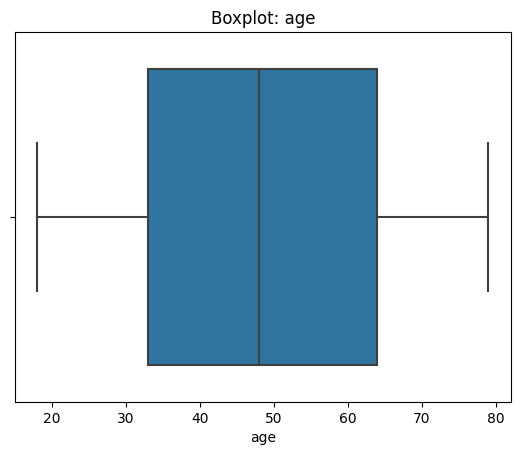

Text(0.5, 1.0, 'Boxplot: cant_mensajes')


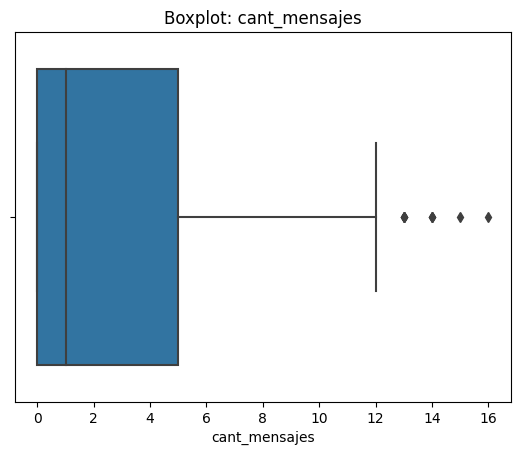

Text(0.5, 1.0, 'Boxplot: cant_llamadas')


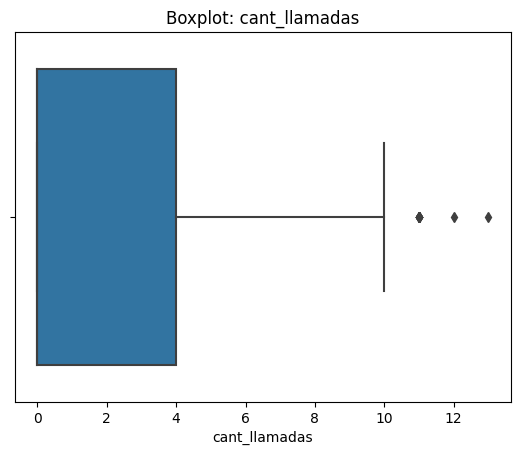

Text(0.5, 1.0, 'Boxplot: cant_min_llamadas')


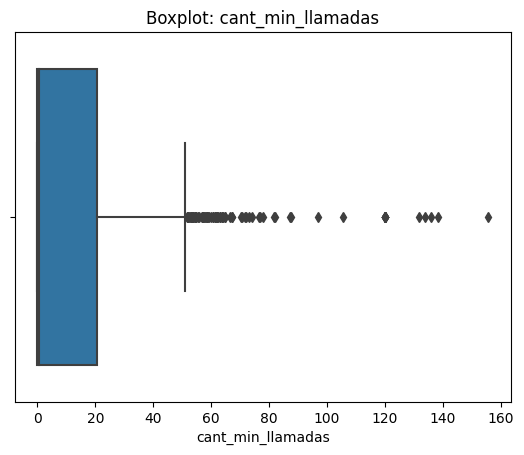

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_min_llamadas']

for col in columnas_numericas:
    sns.boxplot(data=user_profile_2024, x=col)
    print(plt.title(f'Boxplot: {col}'))
    plt.show()


💡Insights:
- Age: ...**No presenta Outliers**
- cant_mensajes: ...**Si presenta Outliers**
- cant_llamadas: ...**Si presenta Outliers**
- cant_minutos_llamada: ...**Si presenta Outliers**

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_min_llamadas']

for col in columnas_limites:
    Q1 = user_profile_2024[col].quantile(0.25)

    #calcular Q3
    Q3 = user_profile_2024[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    print(f'Limite Inferior {col}: ', lower)
    print(f'Limite superior {col}: ', upper)

    print(f'IQR {col}: ', IQR)



Limite Inferior cant_mensajes:  -7.5
Limite superior cant_mensajes:  12.5
IQR cant_mensajes:  5.0
Limite Inferior cant_llamadas:  -6.0
Limite superior cant_llamadas:  10.0
IQR cant_llamadas:  4.0
Limite Inferior cant_min_llamadas:  -30.825000000000003
Limite superior cant_min_llamadas:  51.375
IQR cant_min_llamadas:  20.55


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile_2024[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_min_llamadas
count,2646.00000,2646.000000,2646.000000
mean,2.76455,2.290627,12.127162
std,3.22750,2.737785,17.912313
min,0.00000,0.000000,0.000000
25%,0.00000,0.000000,0.000000
50%,1.00000,0.000000,0.555000
75%,5.00000,4.000000,20.550000
max,16.00000,13.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? **Utilizaré la tecnica de tratamiento de Outliers llamada "CAP" o "Winzorizar con quantile 0.99" pues los datos corresponden a sesgo a la derecha, no son extraños porque pueden ocurrir y puedo ajustar mejor los datos para moderar la varianza en una posible "machine Learning" en el futuro.**
- cant_llamadas: mantener o no outliers, porqué? **Utilizaré la "Winzorizacion con quantile 0.99" para reducir el impacto de la Desv est con el promedio.**
- cant_minutos_llamada: mantener o no outliers, porqué? **Utilizaré la "Winzorizacion con quantile 0.99" para reducir el impacto de la Desv est con el promedio.**

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile_2024["grupo_uso"] = np.where(
        (user_profile_2024['cant_llamadas'] < 5) & (user_profile_2024['cant_mensajes'] < 5), "Bajo uso",
                np.where(
                    (user_profile_2024['cant_llamadas'] < 10) & (user_profile_2024['cant_mensajes'] < 10), "Medio uso", "Alto uso"))


In [ ]:
# verificar cambios
user_profile_2024.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,type,cant_mensajes,cant_llamadas,cant_min_llamadas,grupo_uso
5286,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,call,0.0,3.0,11.50,Bajo uso
5287,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,text,13.0,0.0,0.00,Alto uso
5288,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,call,0.0,7.0,33.27,Medio uso
5289,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,text,3.0,0.0,0.00,Bajo uso
5290,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,2024,call,0.0,7.0,87.56,Medio uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile_2024["grupo_edad"] = np.where(user_profile_2024['age'] < 30, "Joven",
                                           np.where(user_profile_2024['age'] < 60, "Adulto", "Adulto Mayor"))


In [ ]:
# verificar cambios
user_profile_2024.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,type,cant_mensajes,cant_llamadas,cant_min_llamadas,grupo_uso,grupo_edad
5286,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,call,0.0,3.0,11.50,Bajo uso,Joven
5287,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,2024,text,13.0,0.0,0.00,Alto uso,Joven
5288,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,call,0.0,7.0,33.27,Medio uso,Adulto Mayor
5289,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,2024,text,3.0,0.0,0.00,Bajo uso,Adulto Mayor
5290,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,2024,call,0.0,7.0,87.56,Medio uso,Joven


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0.5, 1.0, 'Segmentos por uso')


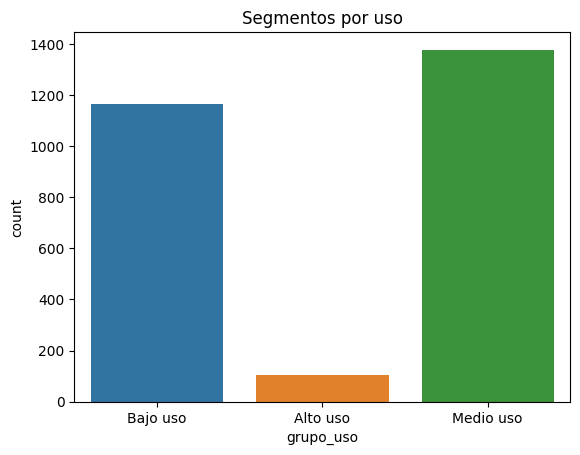

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile_2024, x='grupo_uso')
print(plt.title('Segmentos por uso'))
plt.show()

Text(0.5, 1.0, 'Segmentos por edad')


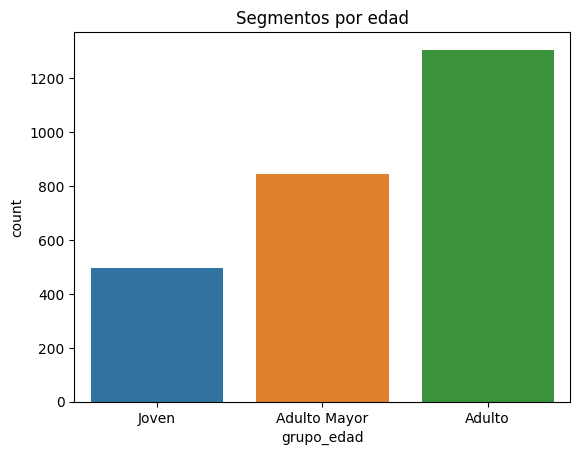

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile_2024, x='grupo_edad')
print(plt.title('Segmentos por edad'))
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? **La columna "city" tenia 11,7% de datos nulos "?"** los cuales se ajustaron a NA para proder obtener evaluar esta columna, **la columna *age* tenia valores no logicos "-999"** los cuales se reemplazaron por la mediana. Se cambio el formato de fecha "reg_date" a "date_time" para poder separar los años y se observo que el año en comun entre tablas es el 2024.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  **Segun edad el segmento de mayor participacion solos "Adultos" y "Adultos mayores" y segun nivel de uso, los segmentos de mayor participacion son "Bajo y Medio uso" con mas de 1100 datos**
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? **El segmento de interes seria los "Adultos" y "Adultos Mayores" con planes de datos de "Bajo y Medio uso" teniendo en cuenta que este sector de edad no permanece mucho tiempo en el telefono.**  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? **El patron de outliers mas evidente fue el de "can_min_llamadas" ya que muy pocos datos eran muy extremos los cuales pueden afectar el plan de datos de interes, sin embargo es claro que la mayoria de personas usa planes de datos de "Bajo y Medio uso"**
Los otros Outliers fueron encontrados en "cant_mensajes" y cant_llamadas" fue los valores extremos estan mas cercanos a la mayoria de datos. Por lo que sacar los outiliers no cambie mucho el promedio y mediana.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados? **El segmento de interes son los clientes "Adultos y Adultos Mayores" por  tal razon me enfocaria en ofrecer precios competitivos para planes ajustados a "Bajo y Medio uso", sin embargo es importante tener presente que la tendencia es que la poblacion tienda a envejecer cada vez mas lo cual hace pensar que el mercado de "Joven" incrementara en los proximos años cuando ellos tengan mayor poder adquisitivo.**


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron datos con "?" en columna "city" que se reemplazaron "NA" para poder consolidar y evaluar esta columna
- Se detectaron datos sentinels "-999" en columna"age que no son logicos y de acuerdo al valor mas representativo se reemplazaron por la mediana
- Se detectaron outliers en "cant_min_llamadas" que se pueden quitar con quantile (0.99)
- En "cant_llamadas" habian muchos datos en "0" que correspondian a texto por tal razon se filtraron datos > 0


🔍 **Segmentos por Edad**
- Los segmentos con mayor participacion son "Adultos" y "Adultos MAyores" con 800 y 1200 datos respectivamente
- El segmento de "Jovenes" posiblemente incremente el proximos años debido al envejecimiento global de la poblacion por tal razon es un segmento de interes.

📊 **Segmentos por Nivel de Uso**
- El nivel de uso de mayor proporción es el de "Bajo uso" y "Medio uso"
- Posiblemente el segmento de "Alto uso" sean datos muy extraños que sean outliers y no se deberían tener presente.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Teniendo en cuenta que el segmento de mayor proporcion es el de "Bajo y Medio uso" y que la poblacion que usa mas el telefono es la poblacion de "Adultos" y "Adultos Mayores" es importante ofrecer planes adecuados para estos segmentos y teniendo en cuenta que el segmento de "jovenes" puede incrementar en los proximos años es importante monitorear el incremento anual para anticiparse a lo que el mercado requiere.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`